## Analisis Numerik: Regresi dan Pencarian Akar Titik Impas (BEP)

NAMA : DHEA ALYA AFKARINA

NPM : 25083010018

## Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [ ]:
url = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"
df = pd.read_csv(url)
df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


## 1. Plot Jumlah Penjualan vs Revenue (30%)

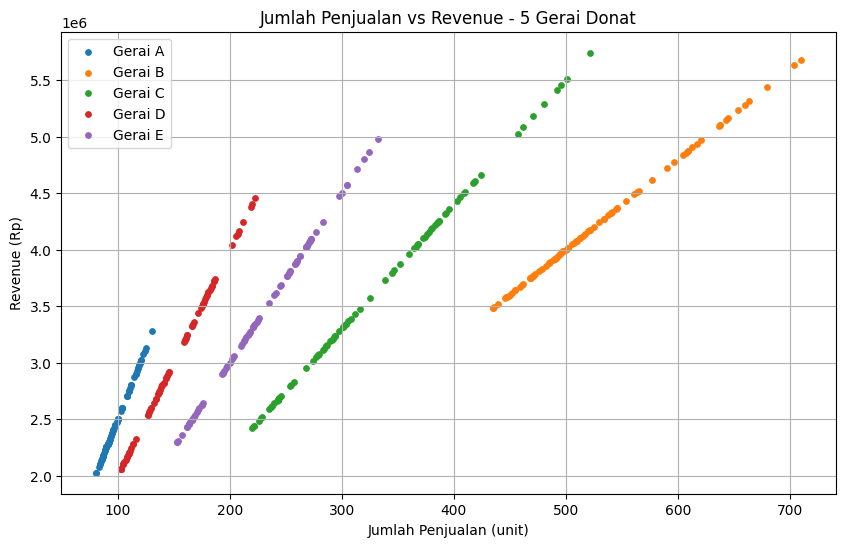

In [ ]:
plt.figure(figsize=(10, 6))
for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]
    plt.scatter(data["Jumlah Terjual (Unit)"], data["Pendapatan Kotor (Rp)"], s=15, label=gerai)

plt.xlabel("Jumlah Penjualan (unit)")
plt.ylabel("Revenue (Rp)")
plt.title("Jumlah Penjualan vs Revenue - 5 Gerai Donat")
plt.legend()
plt.grid(True)
plt.show()

**Interpretasi:** Titik-titik data pada tiap gerai membentuk pola naik yang rapat, menunjukkan hubungan yang kuat antara jumlah penjualan dan revenue. Kemiringan pola berbeda-beda antar gerai karena masing-masing gerai menetapkan harga jual per unit yang berbeda.

## 2. Regresi Bentuk Tren Revenue terhadap Volume Penjualan (30%)

In [ ]:
hasil_regresi_revenue = {}

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai].sort_values("Jumlah Terjual (Unit)")
    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    # model linear
    model_linear = LinearRegression()
    model_linear.fit(X, y)
    r2_linear = r2_score(y, model_linear.predict(X))

    # model polinomial derajat 2
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    r2_poly = r2_score(y, model_poly.predict(X_poly))

    hasil_regresi_revenue[gerai] = {
        "R2_linear": r2_linear,
        "R2_polinomial": r2_poly,
        "slope": model_linear.coef_[0],
        "intercept": model_linear.intercept_,
    }

pd.DataFrame(hasil_regresi_revenue).T

,R2_linear,R2_polinomial,slope,intercept
Gerai A,1.0,1.0,25000.0,0.000000e+00
Gerai B,1.0,1.0,8000.0,9.313226e-10
Gerai C,1.0,1.0,11000.0,0.000000e+00
Gerai D,1.0,1.0,20000.0,0.000000e+00
Gerai E,1.0,1.0,15000.0,-4.656613e-10


**Interpretasi:** Kedua model (linear dan polinomial derajat 2) menghasilkan R² yang hampir sama untuk semua gerai (mendekati 1). Karena revenue = harga jual × jumlah unit dan harga jual tiap gerai konstan, bentuk tren yang paling sesuai adalah **linear**, sehingga model linear (lebih sederhana) yang dipakai pada tahap regresi berikutnya.

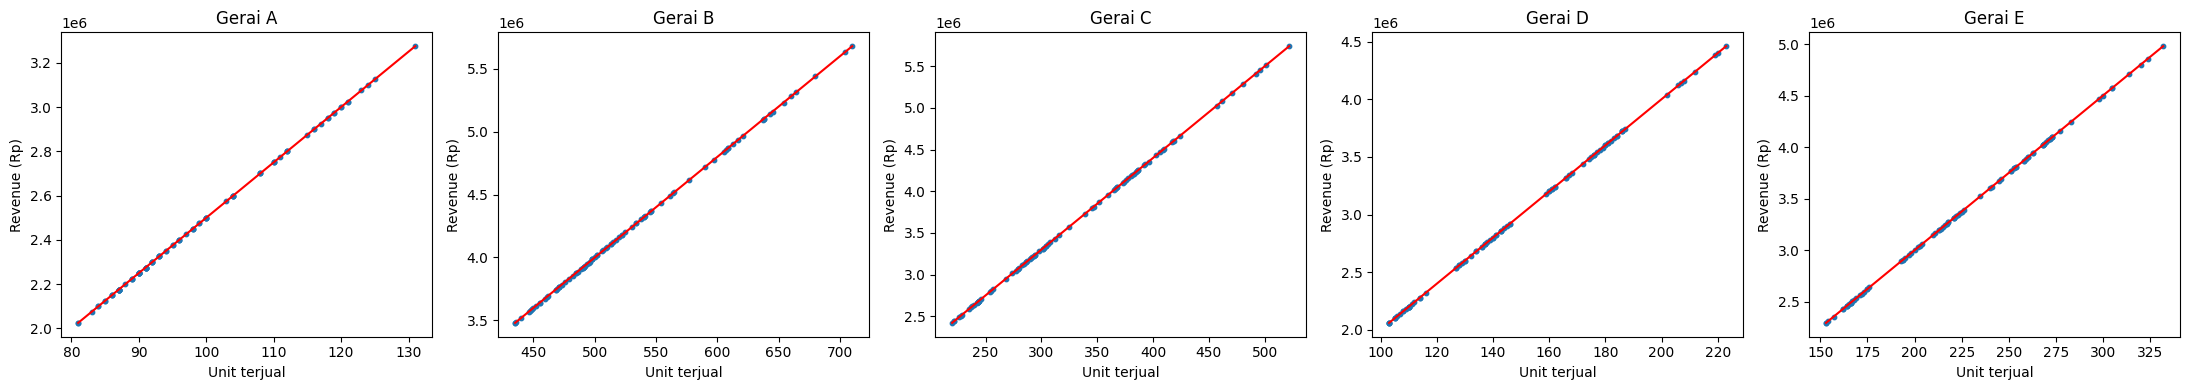

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, gerai in zip(axes, df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai].sort_values("Jumlah Terjual (Unit)")
    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    ax.scatter(X, y, s=10)
    ax.plot(X, model.predict(X), color="red")
    ax.set_title(gerai)
    ax.set_xlabel("Unit terjual")
    ax.set_ylabel("Revenue (Rp)")

plt.tight_layout()
plt.show()

## 3. Regresi Balance & Pencarian BEP dengan Metode Numerik (40%)

BEP tercapai saat Balance (Rp) = 0. Balance merupakan hasil dari Revenue dikurangi seluruh biaya (variabel + fixed), dan mengikuti pola linear yang sama seperti regresi revenue pada tahap sebelumnya. Balance diregresi terhadap volume penjualan, kemudian akar dari persamaan garis tersebut dicari menggunakan metode bisection.

In [ ]:
def bisection(f, a, b, tol=1e-6, max_iter=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) dan f(b) harus berbeda tanda")
    it = 0
    while (b - a) / 2 > tol and it < max_iter:
        c = (a + b) / 2
        fc = f(c)
        if fc == 0:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
        it += 1
    return (a + b) / 2, it

In [ ]:
hasil_bep = {}

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a_koef = model.coef_[0]
    b_koef = model.intercept_
    f = lambda x: a_koef * x + b_koef

    lo, hi = 0.0, 10.0
    while f(lo) * f(hi) > 0:
        hi *= 1.5

    x_bep, n_iter = bisection(f, lo, hi)

    hasil_bep[gerai] = {
        "slope": a_koef,
        "intercept": b_koef,
        "BEP (unit)": x_bep,
        "iterasi": n_iter,
    }

pd.DataFrame(hasil_bep).T

,slope,intercept,BEP (unit),iterasi
Gerai A,16500.0,-1683333.0,102.020181,26.0
Gerai B,3840.0,-733333.0,190.972135,27.0
Gerai C,6160.0,-1733333.0,281.385227,28.0
Gerai D,12800.0,-2666666.0,208.333282,27.0
Gerai E,8700.0,-800000.0,91.954023,26.0


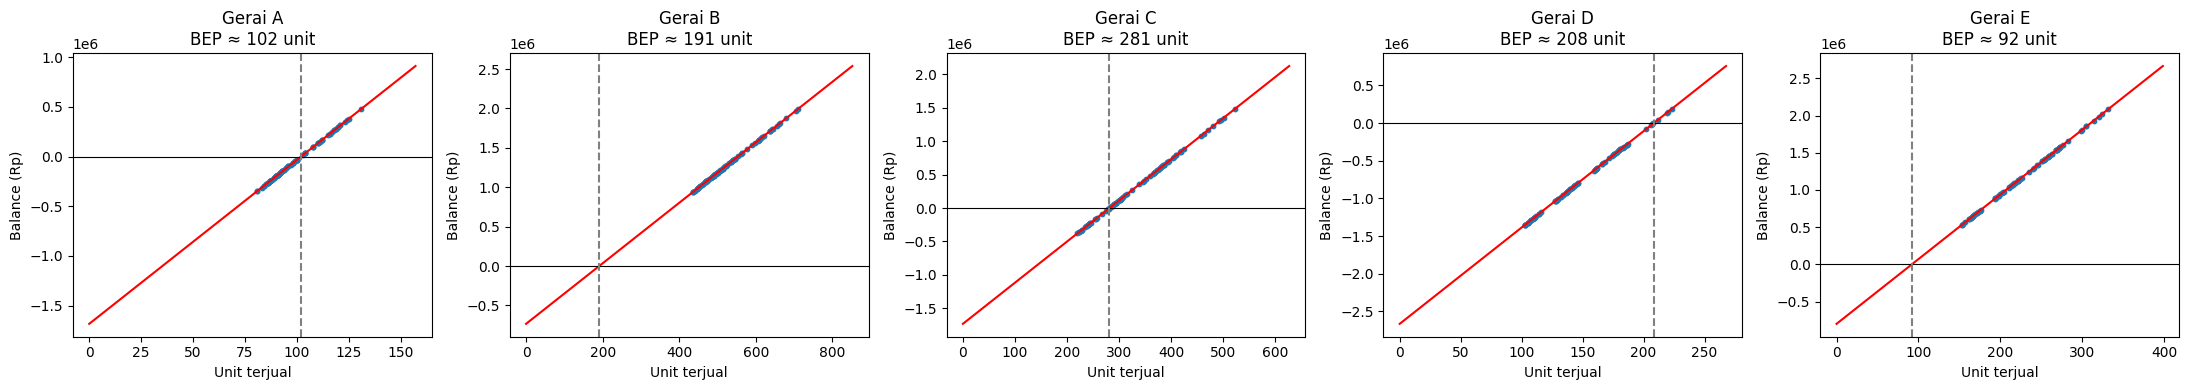

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, gerai in zip(axes, df["Gerai"].unique()):
    data = df[df["Gerai"] == gerai].sort_values("Jumlah Terjual (Unit)")
    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Balance (Rp)"]

    a_koef = hasil_bep[gerai]["slope"]
    b_koef = hasil_bep[gerai]["intercept"]
    bep = hasil_bep[gerai]["BEP (unit)"]

    xs = np.linspace(0, max(X.values.max(), bep) * 1.2, 100)

    ax.scatter(X, y, s=10)
    ax.plot(xs, a_koef * xs + b_koef, color="red")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(bep, color="gray", linestyle="--")
    ax.set_title(f"{gerai}\nBEP \u2248 {bep:.0f} unit")
    ax.set_xlabel("Unit terjual")
    ax.set_ylabel("Balance (Rp)")

plt.tight_layout()
plt.show()

## 4. Ringkasan BEP vs Rata-rata Penjualan

In [ ]:
ringkasan = []
for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]
    avg_jual = data["Jumlah Terjual (Unit)"].mean()
    bep = hasil_bep[gerai]["BEP (unit)"]
    status = "Untung rata-rata" if avg_jual > bep else "Rugi rata-rata"
    ringkasan.append([gerai, round(bep, 1), round(avg_jual, 1), status])

pd.DataFrame(ringkasan, columns=["Gerai", "BEP (unit/hari)", "Rata-rata Jual (unit/hari)", "Status"])

,Gerai,BEP (unit/hari),Rata-rata Jual (unit/hari),Status
0,Gerai A,102.0,99.1,Rugi rata-rata
1,Gerai B,191.0,527.5,Untung rata-rata
2,Gerai C,281.4,328.9,Untung rata-rata
3,Gerai D,208.3,149.8,Rugi rata-rata
4,Gerai E,92.0,226.6,Untung rata-rata


**Kesimpulan:** Gerai dengan rata-rata penjualan di atas nilai BEP hasil regresi berarti secara rata-rata sudah mencapai keuntungan, sedangkan gerai dengan rata-rata penjualan di bawah BEP masih berada pada kondisi rugi secara rata-rata. Perbedaan ini mencerminkan pengaruh strategi marketing masing-masing gerai terhadap struktur harga, biaya variabel, dan fixed cost hariannya.